## 科比生涯数据集分析

### 1.项目目标

通过分析科比职业生涯比赛的相关数据，掌握Numpy, Pandas, Matplotlib, Seaborn等常用数据分析库的用法，掌握常规的数据预处理的方法以及特征工程。掌握建立随机森林模型，模型参数调整，构建最好的模型，预测测试数据，并保存测试数据的方法。

### 2.科比生涯简介

不论你是否看NBA，都应该听说过科比布莱恩特这个名字，它是最接近篮球之神乔丹的运动员。科比于1996年以13顺位的选秀身份进入联盟，一生都效力于洛杉矶湖人队。于2016年宣布退役，职业生涯获奖无数，5次NBA总冠军，2次FMVP，1次MVP，4次AMVP，18次全明星，生涯总得分超33000分，未来的名人堂球员等。在今年的1月26日，科比乘坐的私人飞机不幸失事，科比和二女儿吉安娜永远地离开了我们，这对无数球迷是一个莫大的打击。虽然科比离开了我们，但曼巴精神将激励着一代又一代的年轻人去追逐自己的梦想。

### 3.该数据集简介

该数据集收录了自96赛季~2016赛季，科比整个职业生涯的比赛记录，共有30697条数据。每一条数据都是一次出手记录，其中包括动作类型，投篮类型，投射距离，投射位置，是否命中等25个特征。在该数据集中我们将以是否命中篮筐为标签值来进行分析，带有标签值的数据共25697条。我们将以这25697条数据作为训练数据进行建模，来对不带标签的5000条数据进行预测。

### 4.数据集中各列特征说明

| 列名称             | 含义                                                         |
| ------------------ | ------------------------------------------------------------ |
| action_type        | 动作类型，如跳投，扣篮，上篮                                 |
| combined_shot_type | 组合投篮类型，如跳投，扣篮，勾手，擦板，罚球                 |
| game_event_id      | 比赛的编号                                                   |
| lat                | 出手的纬度                                                   |
| loc_x              | 出手的x坐标                                                  |
| loc_y              | 出手的y坐标                                                  |
| lon                | 出手的经度                                                   |
| minutes_remaining  | 距离比赛结束，还剩多少分钟                                   |
| period             | 交手的场次，取值为1~7                                        |
| playoffs           | 是否是打季后赛                                               |
| season             | 赛季，如13~14赛季                                            |
| seconds_remaining  | 距离比赛结束，还剩多少秒                                     |
| shot_distance      | 出手距离                                                     |
| shot_made_flag     | 是否命中                                                     |
| shot_type          | 投射类型，两分球还是三分球                                   |
| shot_zone_area     | 出手区域，左侧，右侧，中场，后场等                           |
| shot_zone_basic    | 另一种划分出手区域的方式，中线，禁区，油漆区，左侧底角，右侧底角等 |
| shot_zone_range    | 出手区域的距离，小于8英尺，8~16英尺，16~24英尺，24英尺以上等 |
| team_id            | 球队编号                                                     |
| team_name          | 球队名称                                                     |
| game_date          | 比赛日期                                                     |
| matchup            | 对阵双方                                                     |
| opponent           | 对手                                                         |
| game_id            | 比赛的编号                                                   |
| shot_id            | 出手的编号                                                   |



### 5.流程简介

- 读取数据并做简单的描述性统计
- 探索性分析，单变量分析，双变量分析
- 数据与处理和特征工程
- 建立随机森林模型并进行调参，选择最优参数
- 对测试数据进行预测，并保存模型结果





该数据集分析目标：

- 读取科比职业生涯数据集
- 对该数据集进行探索性分析
- 建立集成算法模型
- 模型调参，选择最优的模型参数
- 对测试集进行预测

In [31]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

sklearn库包含机器学习的算法

In [33]:
kobe_data = pd.read_csv(r"D:\JupyterNotebook\PythonFile\Practice\ML-projects-practicing-master\kobe_data.csv")

kobe_data.shape


(30697, 25)

In [34]:

kobe_data.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


数据分为特征数据与标签数据


特征数据有很多：日期，投篮角度，对手，场次等等

标签数据只有两种：是否

In [35]:
 kobe_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [36]:
shot_made_flag = kobe_data["shot_made_flag"]

# pd.isnull(shot_made_flag)

practice_data = kobe_data[pd.notnull(shot_made_flag)]  #kobe_data[ ... ]：布尔索引（Boolean Indexing）根据括号里的 True/False 序列去 “挑人”。保留结果为 True 的行，扔掉 False 的行。

print(practice_data.shape , practice_data.size)

practice_data.head()

(25697, 25) 642425


,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5
5,Jump Shot,Jump Shot,244,20000012,34.0553,-145,-11,-118.4148,9,3,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,6


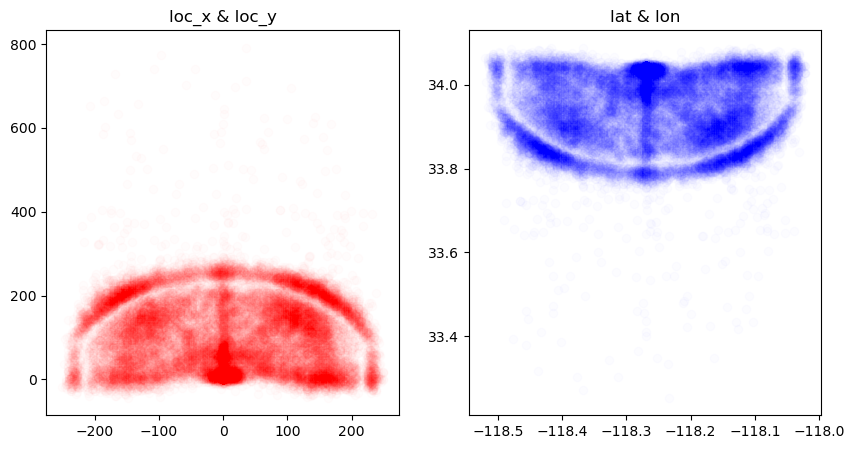

In [37]:
# 分析投篮角度loc_x , loc_y与投中的关系
# 分析出手经纬度lat , lon与投中的关系

fig = plt.figure(figsize = (10,5))

# loc_x & loc_y
plt.subplot(1,2,1)

plt.scatter(practice_data["loc_x"] , practice_data["loc_y"] , color = "r" , alpha = .01)

plt.title("loc_x & loc_y")

# lat & lon
plt.subplot(1,2,2)

plt.scatter(practice_data["lon"] , practice_data["lat"] , color = "b" , alpha = .01)

plt.title("lat & lon")

plt.show()


通过图像分析，投篮角度loc_x , loc_y与投中的关系与出手经纬度lat , lon与投中的关系相同，相当于线性相关 ，因此我们只需要其中一组关系作为训练集中的数据即可

combined_shot_type
Jump Shot    19710
Layup         4532
Dunk          1056
Tip Shot       152
Hook Shot      127
Bank Shot      120
Name: count, dtype: int64


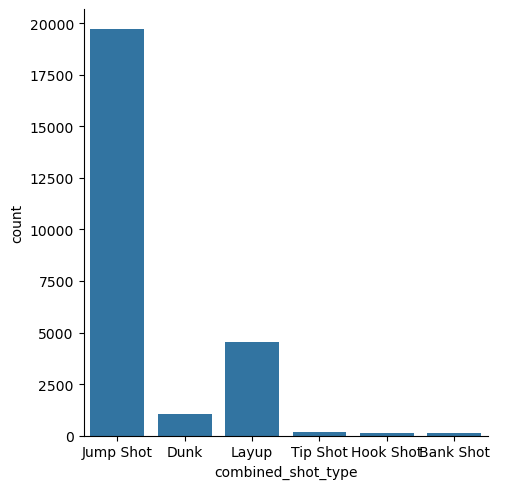

In [38]:
# 科比投篮出手类型的分布

print(practice_data["combined_shot_type"].value_counts())

sns.catplot(data = practice_data , x = practice_data["combined_shot_type"] , kind = "count")

由此可见，科比最喜欢的投篮方式是跳投，其次是上篮

C:\Users\34412\AppData\Local\Temp\ipykernel_3196\344093834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = practice_data , x = practice_data["combined_shot_type"] ,y = practice_data["shot_made_flag"],


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

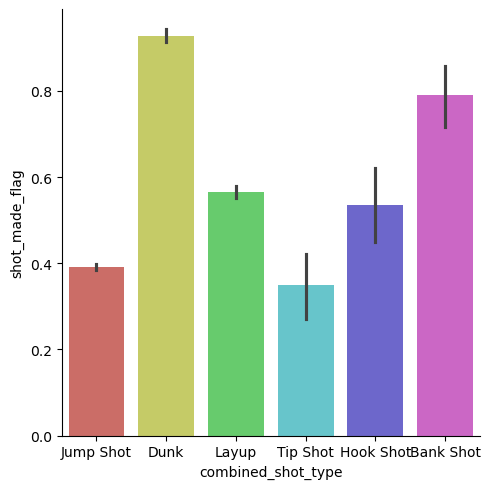

In [39]:
# 查看科比投篮动作命中

sns.catplot(data = practice_data , x = practice_data["combined_shot_type"] ,y = practice_data["shot_made_flag"], 
kind = "bar" , palette = sns.color_palette("hls"))

plt.legend


# sns.barplot(data = practice_data,x = 'combined_shot_type',y = 'shot_made_flag')

由此可见扣篮命中率最高

In [40]:
# 科比三分球和两分球出手次数

print(practice_data["shot_type"].unique())


practice_data["shot_type"].value_counts()


['2PT Field Goal' '3PT Field Goal']


shot_type
2PT Field Goal    20285
3PT Field Goal     5412
Name: count, dtype: int64

可以看出科比喜欢二分投

shot_distance
0     4608
25    1631
24    1263
17    1225
18    1195
      ... 
69       1
53       1
71       1
77       1
79       1
Name: count, Length: 74, dtype: int64


<Axes: xlabel='shot_distance', ylabel='Count'>

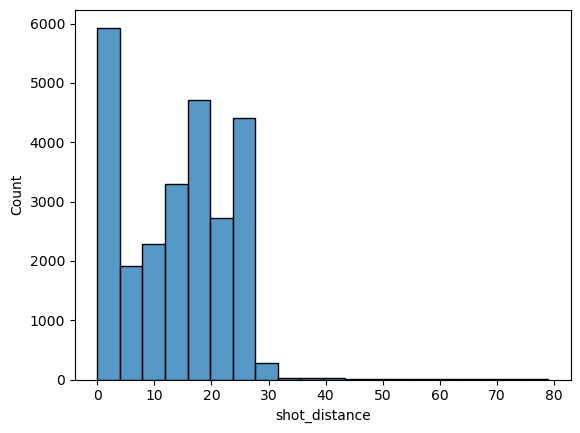

In [41]:
# 查看科比出手的距离分布

print(practice_data["shot_distance"].value_counts())

sns.histplot(
    data=practice_data,
    x="shot_distance",
    bins=20  # 分20个区间
)

C:\Users\34412\AppData\Local\Temp\ipykernel_3196\2197911258.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  practice_data["distance"] = np.sqrt(practice_data["loc_x"]**2 + practice_data["loc_y"]**2)


<Axes: xlabel='distance', ylabel='shot_distance'>

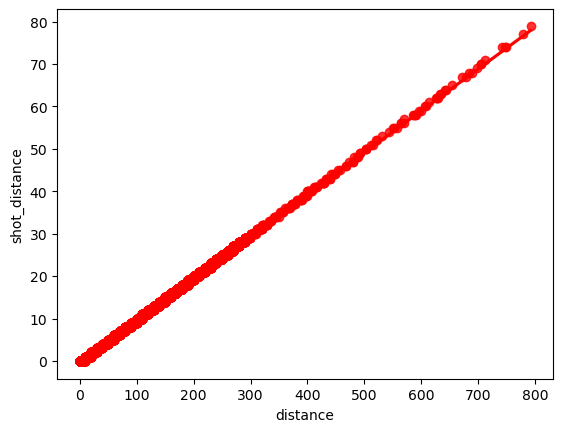

In [42]:
# 查看科比投篮距离与极坐标距离的关系

practice_data["distance"] = np.sqrt(practice_data["loc_x"]**2 + practice_data["loc_y"]**2)


sns.regplot(data = practice_data , x = "distance" , y = "shot_distance" , color = "r")

Text(0.5, 1.0, 'shot_zone_range')

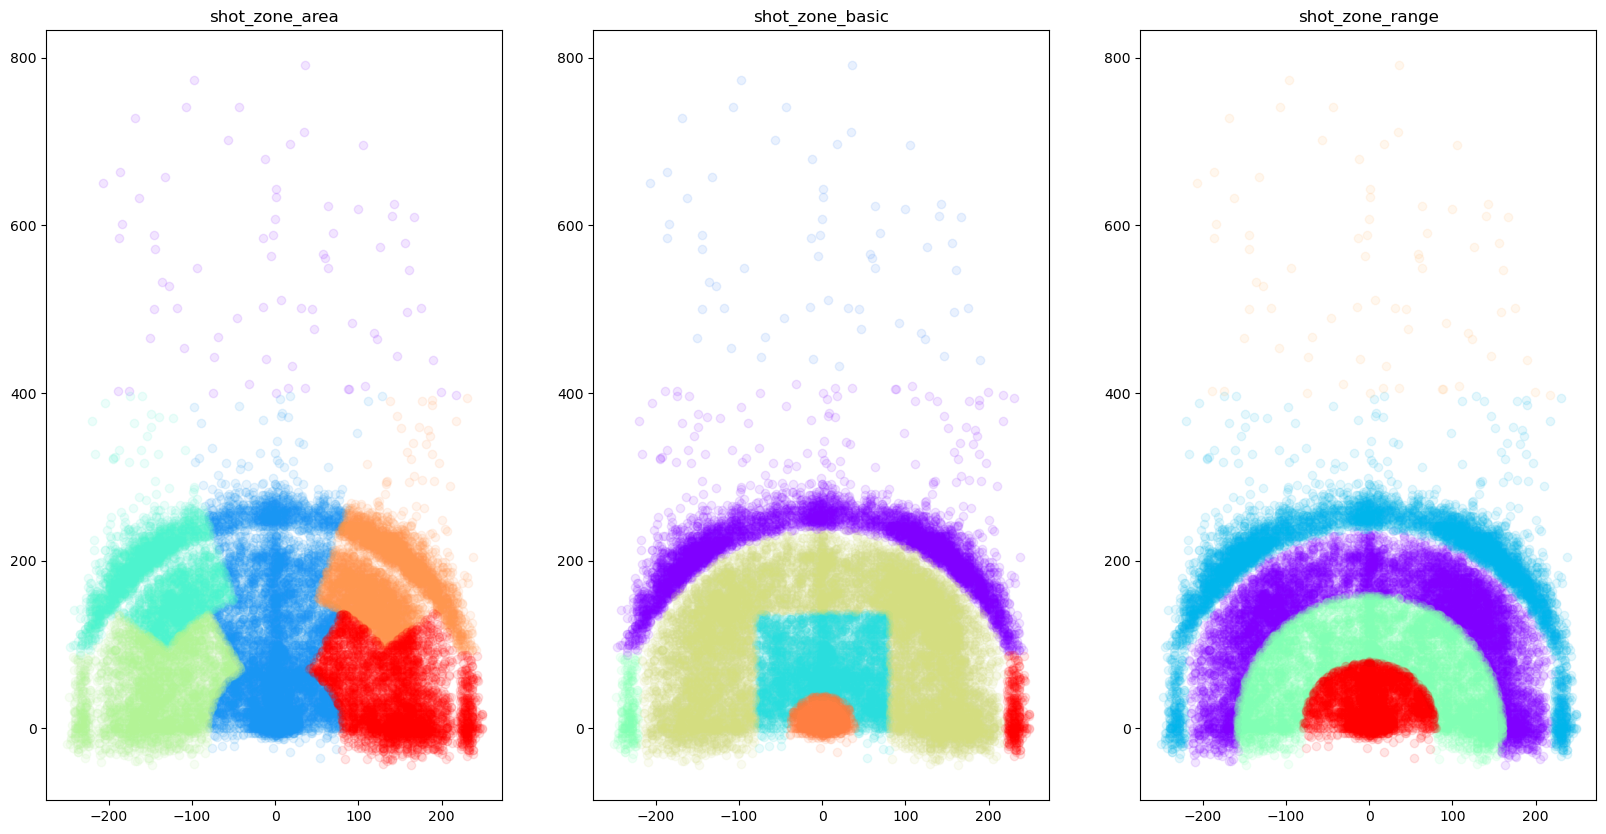

In [43]:
#可视化科比的出手区域，按照不同的标准划分的出手区域
import matplotlib.cm as cm
plt.figure(figsize  = (20,10))

def scatter_plot_by_category(feat):
    alpha = 0.1
    gs = practice_data.groupby(feat) # 按传入的分类列（如shot_zone_area）对数据分组
    cs = cm.rainbow(np.linspace(0,1,len(gs))) # 生成彩虹色配色，为每个分组分配唯一颜色
    for g,c in zip(gs,cs):
        plt.scatter(g[1].loc_x , g[1].loc_y , color = c,alpha = alpha) # g[0]：分组的名字（比如「三分线外」「篮下」）,g[1]：这个分组里的全部投篮数据（用来画散点图
        
plt.subplot(1,3,1)
scatter_plot_by_category(practice_data['shot_zone_area'])
plt.title('shot_zone_area')

plt.subplot(1,3,2)
scatter_plot_by_category(practice_data['shot_zone_basic'])
plt.title('shot_zone_basic')

plt.subplot(1,3,3)
scatter_plot_by_category(practice_data['shot_zone_range'])
plt.title('shot_zone_range')

In [44]:
# 统计分组包含什么g[0]
import matplotlib.cm as cm
def data_category(data):
    alpha = 0.1
    gs = practice_data.groupby(data)
    cs = cm.rainbow(np.linspace(0,1,len(gs))) # 按分组数量，自动生成一组渐变彩虹色，给每组数据分配专属颜色,生成颜色位置在 0～1 之间均匀切分
    for g in gs:
        print(g[0])


data_category(practice_data["shot_zone_area"])




Back Court(BC)
Center(C)
Left Side Center(LC)
Left Side(L)
Right Side Center(RC)
Right Side(R)


In [45]:
gs = practice_data.groupby(practice_data["shot_zone_range"])
for g in gs:
    print(g[0])

16-24 ft.
24+ ft.
8-16 ft.
Back Court Shot
Less Than 8 ft.


In [46]:
# 1. 统计每个区域的投篮次数（最常用！）
practice_data.groupby('shot_zone_area').size()


shot_zone_area
Back Court(BC)              72
Center(C)                11289
Left Side Center(LC)      3364
Left Side(L)              3132
Right Side Center(RC)     3981
Right Side(R)             3859
dtype: int64

In [47]:
# 2. 统计每个区域的平均投篮距离
practice_data.groupby('shot_zone_basic')['shot_distance'].mean()

shot_zone_basic
Above the Break 3        25.563771
Backcourt                58.083333
In The Paint (Non-RA)     8.144330
Left Corner 3            23.029167
Mid-Range                16.565040
Restricted Area           0.412171
Right Corner 3           22.900901
Name: shot_distance, dtype: float64

In [48]:
# 3. 统计每个区域的命中次数
practice_data.groupby('shot_zone_area')['shot_made_flag'].sum()

shot_zone_area
Back Court(BC)              1.0
Center(C)                5933.0
Left Side Center(LC)     1215.0
Left Side(L)             1243.0
Right Side Center(RC)    1523.0
Right Side(R)            1550.0
Name: shot_made_flag, dtype: float64

In [49]:
dis = practice_data.groupby(practice_data["shot_distance"])
dis

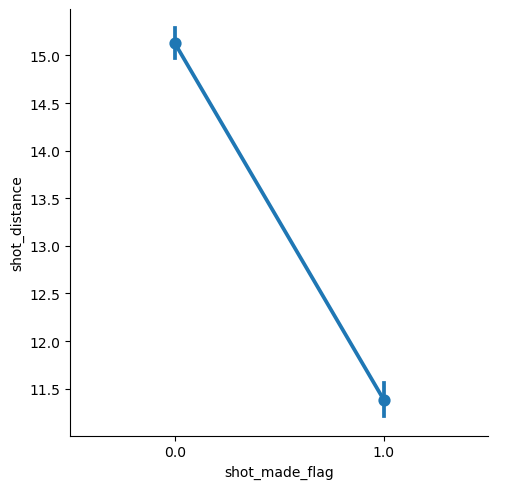

In [50]:
# 观察出手距离与命中率的关系


sns.catplot(data = practice_data , y = "shot_distance" ,x = "shot_made_flag" , kind = "point")



数据预处理，删除不相关的数据与线性相关的数据